**Exploratory Data Analysis**

In [2]:
import sys
print("Python:", sys.executable)

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
import scipy.stats as stats
import statsmodels.api as sm

PROJECT_ROOT = Path("D://Ahmed//Credit_Loan_Risk")
RAW_DATA_PATH   = PROJECT_ROOT / "dataset" / "applications_dataset.csv"
EDA_OUTPUT_PATH = PROJECT_ROOT / "reports" / "eda"
FIGURE_PATH     = PROJECT_ROOT / "reports" / "figures"
# Misc constants used throughout the notebook
RANDOM_STATE   = 94
TARGET_COL     = "TARGET"
ID_COL         = "SK_ID_CURR"
DAYS_EMPLOYED_ANOMALY = 365_243
# Make sure the output folders exist
EDA_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.mkdir(parents=True, exist_ok=True)
# Optional – handy display settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

Python: d:\Ahmed\Credit_Loan_Risk\.venv\Scripts\python.exe


In [3]:

df = pd.read_csv(RAW_DATA_PATH, low_memory=False)


df["EMPLOYED_SENTINEL"] = (df["DAYS_EMPLOYED"] == DAYS_EMPLOYED_ANOMALY).astype(int)
df.loc[df["DAYS_EMPLOYED"] == DAYS_EMPLOYED_ANOMALY, "DAYS_EMPLOYED"] = pd.NA

print("Data shape :", df.shape)
df.head()


Data shape : (307511, 123)


C:\Users\ahmed\AppData\Local\Temp\ipykernel_25676\1061182676.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["EMPLOYED_SENTINEL"] = (df["DAYS_EMPLOYED"] == DAYS_EMPLOYED_ANOMALY).astype(int)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EMPLOYED_SENTINEL
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [4]:

col_dict = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "unique": [df[c].nunique(dropna=True) for c in df.columns],
    "sample_vals": [
        ", ".join(map(str, df[c].dropna().unique()[:5]))
        for c in df.columns
    ],
})

# Show first rows
col_dict.head()
# Save for later reference
col_dict.to_csv(EDA_OUTPUT_PATH / "column_dictionary.csv", index=False)


In [5]:
# Duplicate rows based on the unique application id
# ------------------------------------------------------------------

dup_rows = df.duplicated(subset=[ID_COL]).sum()
dup_summary = pd.DataFrame({
    "duplicate_rows": [dup_rows],
    "total_rows":    [len(df)],
    "unique_rows":   [len(df) - dup_rows],
})

dup_summary
dup_summary.to_csv(EDA_OUTPUT_PATH / "duplicate_summary.csv", index=False)


In [6]:
# Detailed statistics for every column
# ------------------------------------------------------------------
import pandas as pd
import numpy as np


percentiles = [0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]


def detailed_stats(series: pd.Series) -> pd.Series:
    """Return a series with min, max, mean, std, and the custom percentiles."""
    if series.dtype.kind in "bifc":          # numeric / boolean / float / complex
        q = series.quantile(percentiles, interpolation="nearest")
        return pd.Series({
            "count":        series.count(),
            "missing":      series.isna().sum(),
            "missing_pct":  100 * series.isna().mean(),
            "min":          series.min(),
            "max":          series.max(),
            "mean":         series.mean(),
            "std":          series.std(),
            **{f"pct_{int(p*100)}": v for p, v in zip(percentiles, q)}
        })
    else:                                    # non‑numeric (object, category, bool)
        # For categorical data we give count, uniques and top‑k frequencies
        top = series.value_counts().nlargest(5)
        top_str = "; ".join([f"{idx}:{cnt}" for idx, cnt in top.items()])
        return pd.Series({
            "count":        series.count(),
            "missing":      series.isna().sum(),
            "missing_pct":  100 * series.isna().mean(),
            "unique":       series.nunique(dropna=True),
            "top_5":        top_str,
        })

# Apply the helper to every column
stats_df = pd.concat([detailed_stats(df[col]).rename(col) for col in df.columns],
                    axis=1).T


numeric_cols = stats_df[stats_df["mean"].notna()].index.tolist()
categorical_cols = [c for c in stats_df.index if c not in numeric_cols]
ordered = numeric_cols + categorical_cols
stats_df = stats_df.loc[ordered]


stats_df.to_csv(EDA_OUTPUT_PATH / "detailed_statistics.csv")

print(f" Detailed statistics saved to {EDA_OUTPUT_PATH / 'detailed_statistics.csv'}")


 Detailed statistics saved to D:\Ahmed\Credit_Loan_Risk\reports\eda\detailed_statistics.csv


In [7]:
missing_threshold = 0.50
missing_pct = df.isna().mean()
cols_to_drop = missing_pct[missing_pct > missing_threshold].index.tolist()

# Sanity check: how do these correlate with target before dropping?
for col in cols_to_drop:
    if df[col].dtype != 'object':
        flag = df[col].isna().astype(int)
        corr = flag.corr(df[TARGET_COL])
        if abs(corr) > 0.05:  # arbitrary "worth a second look" cutoff
            print(f" {col}: missingness correlates with target ({corr:.3f}) — consider keeping as a flag")

In [8]:
cols_to_keep_anyway = ["OWN_CAR_AGE", "EXT_SOURCE_1"]  # columns to protect from dropping

missing_pct = df.isna().mean()
cols_to_drop = [
    col for col in missing_pct[missing_pct > missing_threshold].index
    if col not in cols_to_keep_anyway
]

print(f"Dropping {len(cols_to_drop)} columns with >{missing_threshold*100}% missing:")
print(cols_to_drop)

df.drop(columns=cols_to_drop, inplace=True)

Dropping 39 columns with >50.0% missing:
['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE']


In [9]:
print(df.shape)

(307511, 84)


In [10]:
# Impute CAR_AGE only where FLAG_OWN_CAR == "Y"
# ------------------------------------------------------------------
# First make sure the flag is numeric (0/1) for easier logic
df["FLAG_OWN_CAR_NUM"] = (df["FLAG_OWN_CAR"] == "Y").astype(int)

# Sentinel: ‑1 (outside any realistic age in days)
sentinel = -1

df["CAR_AGE_IMPUTED"] = df["OWN_CAR_AGE"]                     # copy original
df.loc[df["FLAG_OWN_CAR_NUM"] == 0, "CAR_AGE_IMPUTED"] = sentinel   # no car → sentinel
df.loc[df["FLAG_OWN_CAR_NUM"] == 1, "CAR_AGE_IMPUTED"] = (
    df.loc[df["FLAG_OWN_CAR_NUM"] == 1, "OWN_CAR_AGE"]
    .fillna(df["OWN_CAR_AGE"].median())                      # or any other strategy
)


df.drop(columns=["OWN_CAR_AGE", "FLAG_OWN_CAR"], inplace=True)

In [11]:
# ------------------------------------------------------------------
# Impute EXT_SOURCE_1: flag missingness, then fill with median
# ------------------------------------------------------------------
df["EXT_SOURCE_1_MISSING"] = df["EXT_SOURCE_1"].isna().astype(int)

df["EXT_SOURCE_1_IMPUTED"] = df["EXT_SOURCE_1"].fillna(
    df["EXT_SOURCE_1"].median()
)

# Drop the original now that it's fully captured by the two new columns
df.drop(columns=["EXT_SOURCE_1"], inplace=True)

In [12]:
def impute_column(col_name, strategy="median"):
    """
    Impute a numeric column after the missing‑indicator has been added.
    strategy: "median", "mean", or "constant"
    """
    if strategy == "median":
        fill_val = df[col_name].median()
    elif strategy == "mean":
        fill_val = df[col_name].mean()
    elif strategy == "constant":
        fill_val = -1          # sentinel for “not applicable”
    else:
        raise ValueError("Unsupported strategy")
    
    df[col_name] = df[col_name].fillna(fill_val)

# Example usage:
impute_column("DAYS_EMPLOYED")          # simple median fill
impute_column("AMT_ANNUITY")
impute_column("AMT_GOODS_PRICE")
impute_column("EXT_SOURCE_2")
impute_column("EXT_SOURCE_3")
impute_column("CNT_FAM_MEMBERS")
impute_column("OBS_30_CNT_SOCIAL_CIRCLE")
impute_column("DEF_30_CNT_SOCIAL_CIRCLE")
impute_column("OBS_60_CNT_SOCIAL_CIRCLE")
impute_column("DEF_60_CNT_SOCIAL_CIRCLE")
impute_column("DAYS_LAST_PHONE_CHANGE")

bureau_cols = [
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR",
]
df["BUREAU_REQ_MISSING"] = df["AMT_REQ_CREDIT_BUREAU_YEAR"].isna().astype(int)
for col in bureau_cols:
    df[col] = df[col].fillna(df[col].median())

mode_value = df["NAME_TYPE_SUITE"].mode()[0]
df["NAME_TYPE_SUITE"] = df["NAME_TYPE_SUITE"].fillna(mode_value)

df.loc[df["OCCUPATION_TYPE"].isna() & (df["EMPLOYED_SENTINEL"] == 1), "OCCUPATION_TYPE"] = "Not_Employed"
df.loc[df["OCCUPATION_TYPE"].isna(), "OCCUPATION_TYPE"] = "Unknown"

In [13]:
df.drop(columns=["FLOORSMAX_AVG", "YEARS_BEGINEXPLUATATION_AVG","YEARS_BEGINEXPLUATATION_MODE","FLOORSMAX_MODE","YEARS_BEGINEXPLUATATION_MEDI","FLOORSMAX_MEDI","TOTALAREA_MODE","EMERGENCYSTATE_MODE"], inplace=True)
print(df.shape)

(307511, 78)


**ANALYSIS AFTER DEALING WITH DEAD COLUMNS**

In [14]:
# Apply the helper to every column
stats_df = pd.concat([detailed_stats(df[col]).rename(col) for col in df.columns],
                    axis=1).T


numeric_cols = stats_df[stats_df["mean"].notna()].index.tolist()
categorical_cols = [c for c in stats_df.index if c not in numeric_cols]
ordered = numeric_cols + categorical_cols
stats_df = stats_df.loc[ordered]


stats_df.to_csv(EDA_OUTPUT_PATH / "detailed_statistics_cleaned.csv")

print(f" Detailed statistics saved to {EDA_OUTPUT_PATH / 'detailed_statistics_cleaned.csv'}")
output_path = PROJECT_ROOT / "Dataset" / "non_NA_df.csv"
df.to_csv(output_path, index=False)

 Detailed statistics saved to D:\Ahmed\Credit_Loan_Risk\reports\eda\detailed_statistics_cleaned.csv


**OUTLIER REMOVAL**

In [15]:
days_cols = [
    "DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH", "DAYS_LAST_PHONE_CHANGE"
]

amt_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]

count_cols = [
    "CNT_CHILDREN",
    "OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE",
]

print("=== DAYS columns ===")
print(df[days_cols].describe().T[["min", "max"]])

print("\n=== AMT columns ===")
print(df[amt_cols].describe().T[["min", "max", "mean", "50%"]])

print("\n=== COUNT columns ===")
print(df[count_cols].describe().T[["min", "max", "mean", "50%"]])

print("\n=== CAR_AGE_IMPUTED ===")
print(df["CAR_AGE_IMPUTED"].describe())

=== DAYS columns ===
                            min     max
DAYS_BIRTH             -25229.0 -7489.0
DAYS_EMPLOYED          -17912.0     0.0
DAYS_REGISTRATION      -24672.0     0.0
DAYS_ID_PUBLISH         -7197.0     0.0
DAYS_LAST_PHONE_CHANGE  -4292.0     0.0

=== AMT columns ===
                      min          max           mean       50%
AMT_INCOME_TOTAL  25650.0  117000000.0  168797.919297  147150.0
AMT_CREDIT        45000.0    4050000.0  599025.999706  513531.0
AMT_ANNUITY        1615.5     258025.5   27108.487841   24903.0
AMT_GOODS_PRICE   40500.0    4050000.0  538316.294367  450000.0

=== COUNT columns ===
                          min    max      mean  50%
CNT_CHILDREN              0.0   19.0  0.417052  0.0
OBS_30_CNT_SOCIAL_CIRCLE  0.0  348.0  1.417523  0.0
DEF_30_CNT_SOCIAL_CIRCLE  0.0   34.0  0.142944  0.0
OBS_60_CNT_SOCIAL_CIRCLE  0.0  344.0  1.400626  0.0
DEF_60_CNT_SOCIAL_CIRCLE  0.0   24.0  0.099717  0.0

=== CAR_AGE_IMPUTED ===
count    307511.000000
mean          3

In [16]:
# ------------------------------------------------------------------
# Outlier capping
# ------------------------------------------------------------------

# 1. AMT columns — cap at 99th percentile
for col in ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]:
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper)
    print(f"{col}: capped at {upper:,.1f}")

# 2. CNT_CHILDREN — hard cap at 5
df["CNT_CHILDREN"] = df["CNT_CHILDREN"].clip(upper=5)

# 3. Social circle counts — cap at 99th percentile
for col in ["OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE",
            "OBS_60_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE"]:
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper)
    print(f"{col}: capped at {upper:,.1f}")

# 4. CAR_AGE_IMPUTED — cap only real values (exclude -1 sentinel)
car_mask = df["CAR_AGE_IMPUTED"] != -1
upper_car = df.loc[car_mask, "CAR_AGE_IMPUTED"].quantile(0.99)
df.loc[car_mask, "CAR_AGE_IMPUTED"] = df.loc[car_mask, "CAR_AGE_IMPUTED"].clip(upper=upper_car)
print(f"CAR_AGE_IMPUTED: capped real values at {upper_car:.1f}")

AMT_INCOME_TOTAL: capped at 472,500.0
AMT_CREDIT: capped at 1,854,000.0
AMT_ANNUITY: capped at 70,006.5
AMT_GOODS_PRICE: capped at 1,800,000.0
OBS_30_CNT_SOCIAL_CIRCLE: capped at 10.0
DEF_30_CNT_SOCIAL_CIRCLE: capped at 2.0
OBS_60_CNT_SOCIAL_CIRCLE: capped at 10.0
DEF_60_CNT_SOCIAL_CIRCLE: capped at 2.0
CAR_AGE_IMPUTED: capped real values at 64.0


**ONE HOT ENCODING**

In [17]:
cat_cols = df.select_dtypes(include="object").columns
print(df[cat_cols].nunique().sort_values(ascending=False))

ORGANIZATION_TYPE             58
OCCUPATION_TYPE               20
NAME_INCOME_TYPE               8
WEEKDAY_APPR_PROCESS_START     7
NAME_TYPE_SUITE                7
NAME_HOUSING_TYPE              6
NAME_FAMILY_STATUS             6
NAME_EDUCATION_TYPE            5
CODE_GENDER                    3
FLAG_OWN_REALTY                2
NAME_CONTRACT_TYPE             2
dtype: int64


C:\Users\ahmed\AppData\Local\Temp\ipykernel_25676\2922146908.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


In [18]:
# ------------------------------------------------------------------
# 1. Drop XNA gender rows
# ------------------------------------------------------------------
df = df[df["CODE_GENDER"] != "XNA"].reset_index(drop=True)

# ------------------------------------------------------------------
# 2. Binary encode (2-value columns → 0/1)
# ------------------------------------------------------------------
df["CODE_GENDER"]       = (df["CODE_GENDER"] == "M").astype(int)        # M=1, F=0
df["FLAG_OWN_REALTY"]   = (df["FLAG_OWN_REALTY"] == "Y").astype(int)    # Y=1, N=0
df["NAME_CONTRACT_TYPE"] = (df["NAME_CONTRACT_TYPE"] == "Cash loans").astype(int)  # Cash=1, Revolving=0

# ------------------------------------------------------------------
# 3. Label encode (ordinal)
# ------------------------------------------------------------------
education_order = {
    "Lower secondary"   : 0,
    "Secondary / secondary special" : 1,
    "Incomplete higher" : 2,
    "Higher education"  : 3,
    "Academic degree"   : 4,
}
df["NAME_EDUCATION_TYPE"] = df["NAME_EDUCATION_TYPE"].map(education_order)

# ------------------------------------------------------------------
# 4. One-hot encode (low-cardinality, no ordering)
# ------------------------------------------------------------------
ohe_cols = [
    "OCCUPATION_TYPE",
    "NAME_INCOME_TYPE",
    "WEEKDAY_APPR_PROCESS_START",
    "NAME_TYPE_SUITE",
    "NAME_HOUSING_TYPE",
    "NAME_FAMILY_STATUS",
]

df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

print(f"Shape after encoding: {df.shape}")
print(f"Any remaining object columns: {df.select_dtypes(include='object').columns.tolist()}")

Shape after encoding: (307507, 120)
Any remaining object columns: ['ORGANIZATION_TYPE']


C:\Users\ahmed\AppData\Local\Temp\ipykernel_25676\1211235035.py:40: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Any remaining object columns: {df.select_dtypes(include='object').columns.tolist()}")


In [19]:
# How many defaults vs. repaid?
# ------------------------------------------------------------------
target_counts = (
    df[TARGET_COL]
    .value_counts()
    .rename_axis("target")
    .reset_index(name="count")
)

target_counts["percent"] = (
    target_counts["count"] / target_counts["count"].sum() * 100
)

target_counts
target_counts.to_csv(EDA_OUTPUT_PATH / "target_distribution.csv", index=False)

# Bar chart
sns.barplot(x="target", y="count", data=target_counts, palette="viridis")
plt.title("Target distribution")
plt.xlabel("TARGET (0 = repaid, 1 = default)")
plt.savefig(FIGURE_PATH / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.clf()


C:\Users\ahmed\AppData\Local\Temp\ipykernel_25676\554157963.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="target", y="count", data=target_counts, palette="viridis")


<Figure size 1000x600 with 0 Axes>

**AGGREGATING THE REST OF THE DATASET**

**BUREAU.CSV**

In [20]:
# ------------------------------------------------------------------
# Load and profile bureau.csv
# ------------------------------------------------------------------
bureau = pd.read_csv(PROJECT_ROOT / "Dataset" / "bureau.csv")

print("=== Shape ===")
print(bureau.shape)

print("\n=== Data Types & Non-Null Counts ===")
print(bureau.info())

print("\n=== Missing Values ===")
missing = bureau.isna().mean().sort_values(ascending=False)
print(missing[missing > 0].to_string())

print("\n=== Basic Statistics ===")
print(bureau.describe(include="all").T)

print("\n=== Categorical Columns — Value Counts ===")
cat_cols = bureau.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"\n{col}:")
    print(bureau[col].value_counts(dropna=False).head(10))

=== Shape ===
(1716428, 17)

=== Data Types & Non-Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           str    
 3   CREDIT_CURRENCY         str    
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             str    
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), str(3)
memory usage: 222.6 MB
None

=== Missing Values ===
AMT_ANNUITY               0.714735
AMT_C

C:\Users\ahmed\AppData\Local\Temp\ipykernel_25676\494203374.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = bureau.select_dtypes(include="object").columns


In [21]:
# ------------------------------------------------------------------
#  Drop columns
# ------------------------------------------------------------------
bureau_cols_to_drop = [
    "CREDIT_CURRENCY",
    "CREDIT_DAY_OVERDUE",
    "AMT_CREDIT_MAX_OVERDUE",
    "CNT_CREDIT_PROLONG",
    "AMT_CREDIT_SUM_DEBT",
    "AMT_CREDIT_SUM_LIMIT",
    "AMT_CREDIT_SUM_OVERDUE",
    "AMT_ANNUITY",
]

bureau.drop(columns=bureau_cols_to_drop, inplace=True)
print(f"After dropping columns: {bureau.shape}")
print(f"Remaining columns: {bureau.columns.tolist()}")

After dropping columns: (1716428, 9)
Remaining columns: ['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'DAYS_CREDIT', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_SUM', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE']


In [22]:
# ------------------------------------------------------------------
# Drop Sold and Bad debt rows from CREDIT_ACTIVE
# ------------------------------------------------------------------
print("Before:")
print(bureau["CREDIT_ACTIVE"].value_counts(dropna=False))

bureau = bureau[bureau["CREDIT_ACTIVE"].isin(["Active", "Closed"])].reset_index(drop=True)

print(f"\nAfter dropping Sold/Bad debt rows: {bureau.shape}")
print(bureau["CREDIT_ACTIVE"].value_counts(dropna=False))

Before:
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

After dropping Sold/Bad debt rows: (1709880, 9)
CREDIT_ACTIVE
Closed    1079273
Active     630607
Name: count, dtype: int64


In [23]:
# ------------------------------------------------------------------
# Encode CREDIT_ACTIVE (Active=1, Closed=0)
# ------------------------------------------------------------------
bureau["CREDIT_ACTIVE"] = (bureau["CREDIT_ACTIVE"] == "Active").astype(int)
print("CREDIT_ACTIVE encoded — sample:")
print(bureau["CREDIT_ACTIVE"].value_counts())

CREDIT_ACTIVE encoded — sample:
CREDIT_ACTIVE
0    1079273
1     630607
Name: count, dtype: int64


In [24]:
# ------------------------------------------------------------------
# Handle CREDIT_TYPE
# ------------------------------------------------------------------
print("Before:")
print(bureau["CREDIT_TYPE"].value_counts())

# Bucket into top 2 + Other
bureau["CREDIT_TYPE"] = bureau["CREDIT_TYPE"].apply(
    lambda x: x if x in ["Consumer credit", "Credit card"] else "Other"
)

print("\nAfter bucketing:")
print(bureau["CREDIT_TYPE"].value_counts())

Before:
CREDIT_TYPE
Consumer credit                                 1248403
Credit card                                      400055
Car loan                                          27203
Mortgage                                          17769
Microloan                                         12372
Loan for business development                      1970
Another type of loan                               1003
Unknown type of loan                                555
Loan for working capital replenishment              452
Cash loan (non-earmarked)                            48
Real estate loan                                     25
Loan for the purchase of equipment                   19
Loan for purchase of shares (margin lending)          4
Mobile operator loan                                  1
Interbank credit                                      1
Name: count, dtype: int64

After bucketing:
CREDIT_TYPE
Consumer credit    1248403
Credit card         400055
Other                61422
Nam

In [25]:
# ------------------------------------------------------------------
# Handle DAYS_ENDDATE_FACT (fill NaN with 0)
# ------------------------------------------------------------------
print(f"NaNs before: {bureau['DAYS_ENDDATE_FACT'].isna().sum()}")
bureau["DAYS_ENDDATE_FACT"] = bureau["DAYS_ENDDATE_FACT"].fillna(0)
print(f"NaNs after:  {bureau['DAYS_ENDDATE_FACT'].isna().sum()}")

NaNs before: 628763
NaNs after:  0


In [26]:
# ------------------------------------------------------------------
#  Handle DAYS_CREDIT_ENDDATE (fill NaN + cap outliers)
# ------------------------------------------------------------------
print(f"NaNs before: {bureau['DAYS_CREDIT_ENDDATE'].isna().sum()}")
print(f"Min: {bureau['DAYS_CREDIT_ENDDATE'].min()}, Max: {bureau['DAYS_CREDIT_ENDDATE'].max()}")

# Fill NaN with 0 (no end date recorded)
bureau["DAYS_CREDIT_ENDDATE"] = bureau["DAYS_CREDIT_ENDDATE"].fillna(0)

# Cap outliers at 1st and 99th percentile
lower = bureau["DAYS_CREDIT_ENDDATE"].quantile(0.01)
upper = bureau["DAYS_CREDIT_ENDDATE"].quantile(0.99)
bureau["DAYS_CREDIT_ENDDATE"] = bureau["DAYS_CREDIT_ENDDATE"].clip(lower=lower, upper=upper)

print(f"After capping — Min: {bureau['DAYS_CREDIT_ENDDATE'].min():.0f}, Max: {bureau['DAYS_CREDIT_ENDDATE'].max():.0f}")

NaNs before: 104926
Min: -42060.0, Max: 31199.0
After capping — Min: -2564, Max: 31011


In [27]:
# ------------------------------------------------------------------
#  Cap outliers on AMT_CREDIT_SUM
# ------------------------------------------------------------------
print(f"Before — Min: {bureau['AMT_CREDIT_SUM'].min()}, Max: {bureau['AMT_CREDIT_SUM'].max()}")

# Fill the 13 missing values with median first
bureau["AMT_CREDIT_SUM"] = bureau["AMT_CREDIT_SUM"].fillna(bureau["AMT_CREDIT_SUM"].median())

upper = bureau["AMT_CREDIT_SUM"].quantile(0.99)
bureau["AMT_CREDIT_SUM"] = bureau["AMT_CREDIT_SUM"].clip(upper=upper)

print(f"After  — Min: {bureau['AMT_CREDIT_SUM'].min()}, Max: {bureau['AMT_CREDIT_SUM'].max()}")
print(f"Capped at: {upper:,.0f}")

Before — Min: 0.0, Max: 585000000.0
After  — Min: 0.0, Max: 3600000.0
Capped at: 3,600,000


In [28]:
# ------------------------------------------------------------------
# Final check before aggregation
# ------------------------------------------------------------------
print(f"Shape: {bureau.shape}")
print(f"\nMissing values:")
print(bureau.isna().sum())
print(f"\nData types:")
print(bureau.dtypes)
print(f"\nSample rows:")
print(bureau.head())

Shape: (1709880, 9)

Missing values:
SK_ID_CURR             0
SK_ID_BUREAU           0
CREDIT_ACTIVE          0
DAYS_CREDIT            0
DAYS_CREDIT_ENDDATE    0
DAYS_ENDDATE_FACT      0
AMT_CREDIT_SUM         0
CREDIT_TYPE            0
DAYS_CREDIT_UPDATE     0
dtype: int64

Data types:
SK_ID_CURR               int64
SK_ID_BUREAU             int64
CREDIT_ACTIVE            int64
DAYS_CREDIT              int64
DAYS_CREDIT_ENDDATE    float64
DAYS_ENDDATE_FACT      float64
AMT_CREDIT_SUM         float64
CREDIT_TYPE                str
DAYS_CREDIT_UPDATE       int64
dtype: object

Sample rows:
   SK_ID_CURR  SK_ID_BUREAU  CREDIT_ACTIVE  DAYS_CREDIT  DAYS_CREDIT_ENDDATE  \
0      215354       5714462              0         -497               -153.0   
1      215354       5714463              1         -208               1075.0   
2      215354       5714464              1         -203                528.0   
3      215354       5714465              1         -203                  0.0   
4    

In [29]:
# ==================================================================
#  Aggregation
# ==================================================================

# ------------------------------------------------------------------
#  Aggregate to one row per customer
# ------------------------------------------------------------------

# CREDIT_TYPE dummies before aggregation
bureau_dummies = pd.get_dummies(bureau["CREDIT_TYPE"], prefix="BUREAU_TYPE", dtype=int)
bureau = pd.concat([bureau, bureau_dummies], axis=1).drop(columns=["CREDIT_TYPE"])

bureau_agg = bureau.groupby("SK_ID_CURR").agg(

    # Volume features
    BUREAU_LOAN_COUNT           = ("SK_ID_BUREAU",          "count"),
    BUREAU_ACTIVE_COUNT         = ("CREDIT_ACTIVE",         "sum"),
    BUREAU_CLOSED_COUNT         = ("CREDIT_ACTIVE",         lambda x: (x == 0).sum()),

    # Credit type counts
    BUREAU_CONSUMER_COUNT       = ("BUREAU_TYPE_Consumer credit", "sum"),
    BUREAU_CARD_COUNT           = ("BUREAU_TYPE_Credit card",     "sum"),
    BUREAU_OTHER_COUNT          = ("BUREAU_TYPE_Other",           "sum"),

    # Days credit — how far back do credits go, most recent
    BUREAU_DAYS_CREDIT_MEAN     = ("DAYS_CREDIT",           "mean"),
    BUREAU_DAYS_CREDIT_MIN      = ("DAYS_CREDIT",           "min"),   # oldest credit
    BUREAU_DAYS_CREDIT_MAX      = ("DAYS_CREDIT",           "max"),   # most recent credit

    # End dates
    BUREAU_DAYS_ENDDATE_MEAN    = ("DAYS_CREDIT_ENDDATE",   "mean"),
    BUREAU_DAYS_ENDDATE_MAX     = ("DAYS_CREDIT_ENDDATE",   "max"),

    # Actual end date for closed credits
    BUREAU_ENDDATE_FACT_MEAN    = ("DAYS_ENDDATE_FACT",     "mean"),

    # Credit amounts
    BUREAU_AMT_CREDIT_MEAN      = ("AMT_CREDIT_SUM",        "mean"),
    BUREAU_AMT_CREDIT_MAX       = ("AMT_CREDIT_SUM",        "max"),
    BUREAU_AMT_CREDIT_SUM       = ("AMT_CREDIT_SUM",        "sum"),

    # How recently updated
    BUREAU_DAYS_UPDATE_MEAN     = ("DAYS_CREDIT_UPDATE",    "mean"),
    BUREAU_DAYS_UPDATE_MAX      = ("DAYS_CREDIT_UPDATE",    "max"),   # most recent update

).reset_index()

print(f"Aggregated bureau shape: {bureau_agg.shape}")
print(f"\nMissing values after aggregation: {bureau_agg.isna().sum().sum()}")
print(f"\nSample — customer 215354:")
print(bureau_agg[bureau_agg["SK_ID_CURR"] == 215354].T)

Aggregated bureau shape: (305622, 18)

Missing values after aggregation: 0

Sample — customer 215354:
                                 99050
SK_ID_CURR                2.153540e+05
BUREAU_LOAN_COUNT         1.100000e+01
BUREAU_ACTIVE_COUNT       6.000000e+00
BUREAU_CLOSED_COUNT       5.000000e+00
BUREAU_CONSUMER_COUNT     7.000000e+00
BUREAU_CARD_COUNT         3.000000e+00
BUREAU_OTHER_COUNT        1.000000e+00
BUREAU_DAYS_CREDIT_MEAN  -7.278182e+02
BUREAU_DAYS_CREDIT_MIN   -1.872000e+03
BUREAU_DAYS_CREDIT_MAX   -4.300000e+01
BUREAU_DAYS_ENDDATE_MEAN  2.441182e+03
BUREAU_DAYS_ENDDATE_MAX   2.746000e+04
BUREAU_ENDDATE_FACT_MEAN -4.044545e+02
BUREAU_AMT_CREDIT_MEAN    5.430859e+05
BUREAU_AMT_CREDIT_MAX     2.700000e+06
BUREAU_AMT_CREDIT_SUM     5.973945e+06
BUREAU_DAYS_UPDATE_MEAN  -3.672727e+02
BUREAU_DAYS_UPDATE_MAX   -1.600000e+01


In [30]:
# ------------------------------------------------------------------
#  Join onto main df
# ------------------------------------------------------------------

# Confirm SK_ID_CURR still exists in df
print(f"SK_ID_CURR in df: {'SK_ID_CURR' in df.columns}")
print(f"df shape before join: {df.shape}")

df = df.merge(bureau_agg, on="SK_ID_CURR", how="left")

print(f"df shape after join: {df.shape}")
print(f"\nNaNs introduced by join (first-time borrowers with no bureau history):")
bureau_cols = [c for c in df.columns if c.startswith("BUREAU_")]
print(df[bureau_cols].isna().sum())

SK_ID_CURR in df: True
df shape before join: (307507, 120)
df shape after join: (307507, 137)

NaNs introduced by join (first-time borrowers with no bureau history):
BUREAU_REQ_MISSING              0
BUREAU_LOAN_COUNT           44196
BUREAU_ACTIVE_COUNT         44196
BUREAU_CLOSED_COUNT         44196
BUREAU_CONSUMER_COUNT       44196
BUREAU_CARD_COUNT           44196
BUREAU_OTHER_COUNT          44196
BUREAU_DAYS_CREDIT_MEAN     44196
BUREAU_DAYS_CREDIT_MIN      44196
BUREAU_DAYS_CREDIT_MAX      44196
BUREAU_DAYS_ENDDATE_MEAN    44196
BUREAU_DAYS_ENDDATE_MAX     44196
BUREAU_ENDDATE_FACT_MEAN    44196
BUREAU_AMT_CREDIT_MEAN      44196
BUREAU_AMT_CREDIT_MAX       44196
BUREAU_AMT_CREDIT_SUM       44196
BUREAU_DAYS_UPDATE_MEAN     44196
BUREAU_DAYS_UPDATE_MAX      44196
dtype: int64


In [31]:
# ------------------------------------------------------------------
#  Fill NaNs from join with 0
# ------------------------------------------------------------------
# NaN here means no bureau history — not unknown, genuinely zero
df[bureau_cols] = df[bureau_cols].fillna(0)

print(f"NaNs after filling: {df[bureau_cols].isna().sum().sum()}")
print(f"Final df shape: {df.shape}")

NaNs after filling: 0
Final df shape: (307507, 137)


**TRAIN TEST SPLIT**

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["TARGET", "ORGANIZATION_TYPE"])  
y = df["TARGET"]
org_type = df["ORGANIZATION_TYPE"]  # keep separate for target encoding later

X_train, X_test, y_train, y_test, org_train, org_test = train_test_split(
    X, y, org_type,
    test_size=0.2,
    random_state=912,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target rate — Train: {y_train.mean():.4f}, Test: {y_test.mean():.4f}")

Train: (246005, 135), Test: (61502, 135)
Target rate — Train: 0.0807, Test: 0.0807


In [33]:
days_cols = [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "DAYS_LAST_PHONE_CHANGE"
]

for col in days_cols:
    X_train[col] = X_train[col].abs()
    X_test[col]  = X_test[col].abs()

In [34]:
# ------------------------------------------------------------------
# Target encode ORGANIZATION_TYPE (fit on train only)
# ------------------------------------------------------------------
# Compute mean target rate per category on training data only
target_encoding_map = y_train.groupby(org_train.values).mean()

# Apply to both train and test
X_train["ORGANIZATION_TYPE"] = org_train.map(target_encoding_map)
X_test["ORGANIZATION_TYPE"]  = org_test.map(target_encoding_map)

# Sanity check — should be no NaNs unless test has unseen categories
print("NaNs in ORGANIZATION_TYPE after encoding:")
print(f"  Train: {X_train['ORGANIZATION_TYPE'].isna().sum()}")
print(f"  Test:  {X_test['ORGANIZATION_TYPE'].isna().sum()}")

print("\nSample of encoding map (category → default rate):")
print(target_encoding_map.sort_values(ascending=False).head(10))

NaNs in ORGANIZATION_TYPE after encoding:
  Train: 0
  Test:  0

Sample of encoding map (category → default rate):
Transport: type 3    0.160169
Industry: type 8     0.157895
Restaurant           0.118384
Industry: type 13    0.117647
Construction         0.115191
Cleaning             0.114833
Industry: type 1     0.112981
Realtor              0.111111
Industry: type 3     0.109470
Agriculture          0.103764
Name: TARGET, dtype: float64


**CORRELATION ANALYSIS**

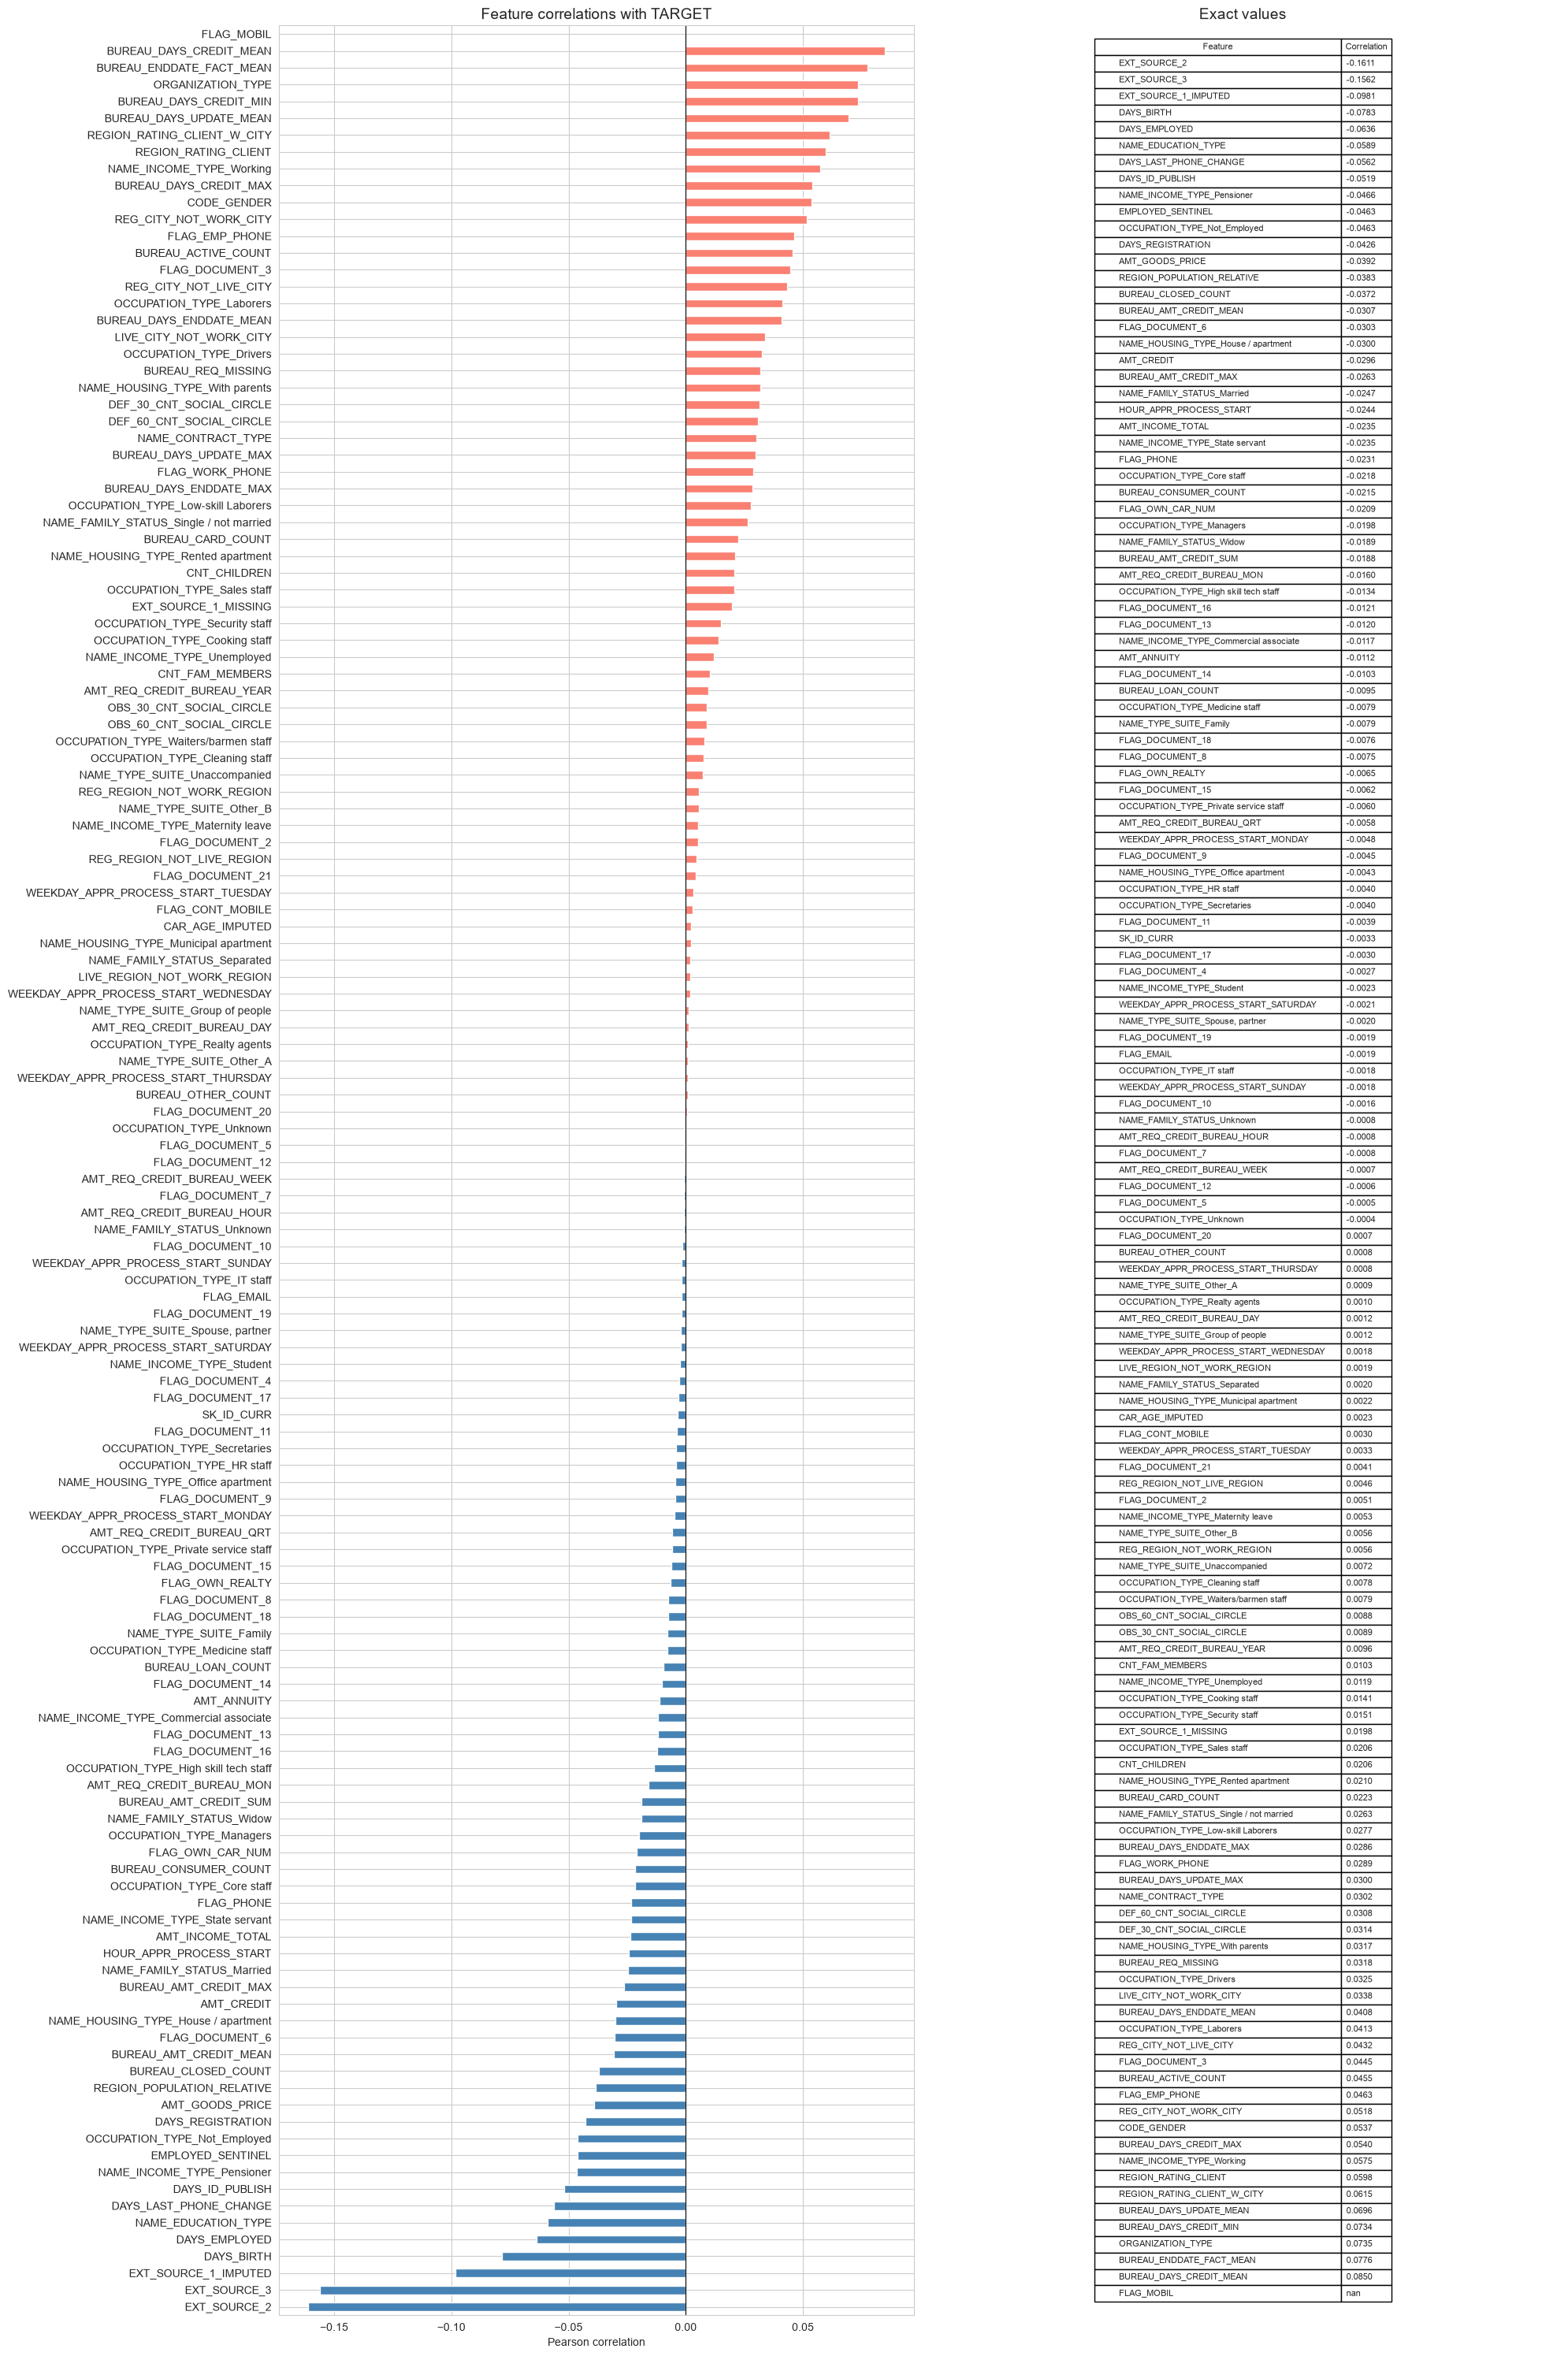


=== Pairs with correlation > 0.9 (9 pairs) ===
  OCCUPATION_TYPE_Not_Employed ↔ EMPLOYED_SENTINEL: 1.000
  NAME_INCOME_TYPE_Pensioner ↔ EMPLOYED_SENTINEL: 1.000
  NAME_INCOME_TYPE_Pensioner ↔ OCCUPATION_TYPE_Not_Employed: 1.000
  OBS_60_CNT_SOCIAL_CIRCLE ↔ OBS_30_CNT_SOCIAL_CIRCLE: 0.998
  AMT_GOODS_PRICE ↔ AMT_CREDIT: 0.986
  REGION_RATING_CLIENT_W_CITY ↔ REGION_RATING_CLIENT: 0.951
  BUREAU_CONSUMER_COUNT ↔ BUREAU_LOAN_COUNT: 0.943
  BUREAU_CLOSED_COUNT ↔ BUREAU_LOAN_COUNT: 0.933
  BUREAU_CONSUMER_COUNT ↔ BUREAU_CLOSED_COUNT: 0.929

=== Pairs with correlation > 0.8 (17 pairs) ===
  OCCUPATION_TYPE_Not_Employed ↔ EMPLOYED_SENTINEL: 1.000
  NAME_INCOME_TYPE_Pensioner ↔ EMPLOYED_SENTINEL: 1.000
  NAME_INCOME_TYPE_Pensioner ↔ OCCUPATION_TYPE_Not_Employed: 1.000
  OBS_60_CNT_SOCIAL_CIRCLE ↔ OBS_30_CNT_SOCIAL_CIRCLE: 0.998
  AMT_GOODS_PRICE ↔ AMT_CREDIT: 0.986
  REGION_RATING_CLIENT_W_CITY ↔ REGION_RATING_CLIENT: 0.951
  BUREAU_CONSUMER_COUNT ↔ BUREAU_LOAN_COUNT: 0.943
  BUREAU_CLOSED_COU

In [35]:
# ------------------------------------------------------------------
# 1. Target correlation — full sorted bar chart + numbers
# ------------------------------------------------------------------
train_full = X_train.copy()
train_full["TARGET"] = y_train.values
corr_matrix = train_full.corr()

target_corr = corr_matrix["TARGET"].drop("TARGET").sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 30))

# Bar chart
colors = ["salmon" if v > 0 else "steelblue" for v in target_corr]
target_corr.plot(kind="barh", ax=ax1, color=colors)
ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_title("Feature correlations with TARGET", fontsize=14)
ax1.set_xlabel("Pearson correlation")

# Numbers table
ax2.axis("off")
table_data = [[feat, f"{val:.4f}"] for feat, val in target_corr.items()]
table = ax2.table(
    cellText=table_data,
    colLabels=["Feature", "Correlation"],
    loc="center",
    cellLoc="left"
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width([0, 1])
ax2.set_title("Exact values", fontsize=14)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "target_correlations.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 2. Feature pairs at multiple thresholds
# ------------------------------------------------------------------
upper = corr_matrix.drop(columns="TARGET").drop(index="TARGET")
upper = upper.where(np.triu(np.ones(upper.shape), k=1).astype(bool))

for threshold in [0.90, 0.80, 0.70, 0.60]:
    pairs = [
        (col, row, upper.loc[row, col])
        for col in upper.columns
        for row in upper.index
        if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > threshold
    ]
    pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
    print(f"\n=== Pairs with correlation > {threshold} ({len(pairs)} pairs) ===")
    for col1, col2, val in pairs:
        print(f"  {col1} ↔ {col2}: {val:.3f}")

In [36]:
print("=== Top 20 NEGATIVE correlations with TARGET ===")
print(target_corr.head(20).to_string())

print("\n=== Top 20 POSITIVE correlations with TARGET ===")
print(target_corr.tail(20).to_string())

=== Top 20 NEGATIVE correlations with TARGET ===
EXT_SOURCE_2                          -0.161127
EXT_SOURCE_3                          -0.156226
EXT_SOURCE_1_IMPUTED                  -0.098141
DAYS_BIRTH                            -0.078328
DAYS_EMPLOYED                         -0.063627
NAME_EDUCATION_TYPE                   -0.058907
DAYS_LAST_PHONE_CHANGE                -0.056181
DAYS_ID_PUBLISH                       -0.051924
NAME_INCOME_TYPE_Pensioner            -0.046557
EMPLOYED_SENTINEL                     -0.046271
OCCUPATION_TYPE_Not_Employed          -0.046268
DAYS_REGISTRATION                     -0.042634
AMT_GOODS_PRICE                       -0.039246
REGION_POPULATION_RELATIVE            -0.038300
BUREAU_CLOSED_COUNT                   -0.037181
BUREAU_AMT_CREDIT_MEAN                -0.030699
FLAG_DOCUMENT_6                       -0.030295
NAME_HOUSING_TYPE_House / apartment   -0.030030
AMT_CREDIT                            -0.029572
BUREAU_AMT_CREDIT_MAX                 -

In [37]:
# Find all zero-variance columns
zero_var_cols = [col for col in X_train.columns if X_train[col].nunique() == 1]
print(f"Zero variance columns: {zero_var_cols}")

# Drop from both train and test
X_train.drop(columns=zero_var_cols, inplace=True)
X_test.drop(columns=zero_var_cols, inplace=True)

print(f"Dropped {len(zero_var_cols)} columns. New shape: {X_train.shape}")

Zero variance columns: ['FLAG_MOBIL']
Dropped 1 columns. New shape: (246005, 135)


In [38]:
# ------------------------------------------------------------------
#  Engineer new features FIRST (before any drops)
# ------------------------------------------------------------------
for df_ in [X_train, X_test]:
    # Loan burden relative to income
    df_["ANNUITY_INCOME_RATIO"]  = df_["AMT_ANNUITY"]  / df_["AMT_INCOME_TOTAL"]
    df_["CREDIT_INCOME_RATIO"]   = df_["AMT_CREDIT"]   / df_["AMT_INCOME_TOTAL"]

    # Implied loan duration in months
    df_["CREDIT_TERM"]           = df_["AMT_CREDIT"]   / df_["AMT_ANNUITY"]

    # Employment as fraction of life
    df_["EMPLOYED_TO_AGE_RATIO"] = df_["DAYS_EMPLOYED"] / df_["DAYS_BIRTH"]

    # Loan amount vs goods price
    df_["CREDIT_TO_GOODS_RATIO"] = df_["AMT_CREDIT"]   / df_["AMT_GOODS_PRICE"]

    # Address instability score
    df_["ADDRESS_MISMATCH"]      = (
        df_["REG_CITY_NOT_WORK_CITY"] +
        df_["REG_CITY_NOT_LIVE_CITY"] +
        df_["LIVE_CITY_NOT_WORK_CITY"]
    )

    # Social circle default rate (needs OBS_60 — must be before drops)
    df_["SOCIAL_DEFAULT_RATE_30"] = (
        df_["DEF_30_CNT_SOCIAL_CIRCLE"] / (df_["OBS_30_CNT_SOCIAL_CIRCLE"] + 1e-5)
    )
    df_["SOCIAL_DEFAULT_RATE_60"] = (
        df_["DEF_60_CNT_SOCIAL_CIRCLE"] / (df_["OBS_60_CNT_SOCIAL_CIRCLE"] + 1e-5)
    )
    df_["BUREAU_ACTIVE_RATIO"] = df["BUREAU_ACTIVE_COUNT"] / (df["BUREAU_LOAN_COUNT"] + 1e-5)
    
print("Engineered features added:")
new_features = [
    "ANNUITY_INCOME_RATIO", "CREDIT_INCOME_RATIO", "CREDIT_TERM",
    "EMPLOYED_TO_AGE_RATIO", "CREDIT_TO_GOODS_RATIO", "ADDRESS_MISMATCH",
    "SOCIAL_DEFAULT_RATE_30", "SOCIAL_DEFAULT_RATE_60", "BUREAU_ACTIVE_RATIO"
]
print(X_train[new_features].describe().T[["min", "max", "mean"]])

Engineered features added:
                             min        max       mean
ANNUITY_INCOME_RATIO    0.008700   1.875965   0.180815
CREDIT_INCOME_RATIO     0.095238  72.280702   3.957792
CREDIT_TERM             6.324539  59.560354  21.610575
EMPLOYED_TO_AGE_RATIO   0.000000   0.728811   0.142454
CREDIT_TO_GOODS_RATIO   0.150000   6.000000   1.121947
ADDRESS_MISMATCH        0.000000   3.000000   0.488523
SOCIAL_DEFAULT_RATE_30  0.000000   0.999995   0.065742
SOCIAL_DEFAULT_RATE_60  0.000000   0.999995   0.049783
BUREAU_ACTIVE_RATIO     0.000000   0.999999   0.354873


C:\Users\ahmed\AppData\Local\Temp\ipykernel_25676\403545599.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_["SOCIAL_DEFAULT_RATE_60"] = (
C:\Users\ahmed\AppData\Local\Temp\ipykernel_25676\403545599.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_["BUREAU_ACTIVE_RATIO"] = df["BUREAU_ACTIVE_COUNT"] / (df["BUREAU_LOAN_COUNT"] + 1e-5)
C:\Users\ahmed\AppData\Local\Temp\ipykernel_25676\403545599.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times,

In [39]:
# ------------------------------------------------------------------
#  Drop redundant columns
# ------------------------------------------------------------------
cols_to_drop_redundant = [
    "EMPLOYED_SENTINEL",                # perfect overlap with NAME_INCOME_TYPE_Pensioner
    "OCCUPATION_TYPE_Not_Employed",     # perfect overlap with NAME_INCOME_TYPE_Pensioner
    "OBS_60_CNT_SOCIAL_CIRCLE",         # 0.998 with OBS_30, replaced by SOCIAL_DEFAULT_RATE_60
    "REGION_RATING_CLIENT",             # 0.951 with REGION_RATING_CLIENT_W_CITY
    "LIVE_REGION_NOT_WORK_REGION",      # 0.860 with REG_REGION_NOT_WORK_REGION
    "CNT_FAM_MEMBERS",                  # 0.878 with CNT_CHILDREN
]

X_train.drop(columns=cols_to_drop_redundant, inplace=True)
X_test.drop(columns=cols_to_drop_redundant, inplace=True)

print(f"Dropped {len(cols_to_drop_redundant)} redundant columns. Shape: {X_train.shape}")

Dropped 6 redundant columns. Shape: (246005, 138)


In [40]:
# ------------------------------------------------------------------
# Drop columns replaced by engineered features
# ------------------------------------------------------------------
cols_to_drop_replaced = [
    "AMT_GOODS_PRICE",          # replaced by CREDIT_TO_GOODS_RATIO
    "LIVE_CITY_NOT_WORK_CITY",  # absorbed into ADDRESS_MISMATCH
    "REG_CITY_NOT_LIVE_CITY",   # absorbed into ADDRESS_MISMATCH
    "REG_CITY_NOT_WORK_CITY",   # absorbed into ADDRESS_MISMATCH
    "DEF_30_CNT_SOCIAL_CIRCLE", # replaced by SOCIAL_DEFAULT_RATE_30
    "DEF_60_CNT_SOCIAL_CIRCLE", # replaced by SOCIAL_DEFAULT_RATE_60
]

X_train.drop(columns=cols_to_drop_replaced, inplace=True)
X_test.drop(columns=cols_to_drop_replaced, inplace=True)

print(f"Dropped {len(cols_to_drop_replaced)} replaced columns. Shape: {X_train.shape}")

Dropped 6 replaced columns. Shape: (246005, 132)


In [41]:
# ------------------------------------------------------------------
#Sanity check
# ------------------------------------------------------------------
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nAny NaNs in X_train: {X_train.isna().sum().sum()}")
print(f"Any NaNs in X_test:  {X_test.isna().sum().sum()}")
print(f"\nAny inf values in X_train: {np.isinf(X_train).sum().sum()}")
print(f"Any inf values in X_test:  {np.isinf(X_test).sum().sum()}")
print(f"\nRemaining object columns: {X_train.select_dtypes(include='object').columns.tolist()}")

X_train shape: (246005, 132)
X_test shape:  (61502, 132)



Any NaNs in X_train: 0
Any NaNs in X_test:  0

Any inf values in X_train: 0
Any inf values in X_test:  0

Remaining object columns: []


In [42]:
ratio_cols = [
    "ANNUITY_INCOME_RATIO", "CREDIT_INCOME_RATIO", "CREDIT_TERM",
    "EMPLOYED_TO_AGE_RATIO", "CREDIT_TO_GOODS_RATIO",
    "SOCIAL_DEFAULT_RATE_30", "SOCIAL_DEFAULT_RATE_60", "BUREAU_ACTIVE_RATIO"
]

new_feature_corrs = X_train[ratio_cols].corrwith(y_train).sort_values()
print(new_feature_corrs)

EMPLOYED_TO_AGE_RATIO    -0.049812
CREDIT_TERM              -0.031855
CREDIT_INCOME_RATIO      -0.006711
ANNUITY_INCOME_RATIO      0.015276
SOCIAL_DEFAULT_RATE_60    0.026380
SOCIAL_DEFAULT_RATE_30    0.027807
BUREAU_ACTIVE_RATIO       0.050810
CREDIT_TO_GOODS_RATIO     0.069329
dtype: float64


In [43]:
full_corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print(full_corr.to_string())

EXT_SOURCE_2                               0.161127
EXT_SOURCE_3                               0.156226
EXT_SOURCE_1_IMPUTED                       0.098141
BUREAU_DAYS_CREDIT_MEAN                    0.084970
DAYS_BIRTH                                 0.078328
BUREAU_ENDDATE_FACT_MEAN                   0.077592
ORGANIZATION_TYPE                          0.073505
BUREAU_DAYS_CREDIT_MIN                     0.073413
BUREAU_DAYS_UPDATE_MEAN                    0.069606
CREDIT_TO_GOODS_RATIO                      0.069329
DAYS_EMPLOYED                              0.063627
REGION_RATING_CLIENT_W_CITY                0.061500
NAME_EDUCATION_TYPE                        0.058907
NAME_INCOME_TYPE_Working                   0.057543
DAYS_LAST_PHONE_CHANGE                     0.056181
BUREAU_DAYS_CREDIT_MAX                     0.053984
CODE_GENDER                                0.053738
ADDRESS_MISMATCH                           0.052872
DAYS_ID_PUBLISH                            0.051924
BUREAU_ACTIV

In [44]:
# ------------------------------------------------------------------
#  Drop low correlation features (threshold < 0.01)
# ------------------------------------------------------------------
full_corr = X_train.corrwith(y_train).abs()

# Everything below threshold
low_corr_cols = full_corr[full_corr < 0.01].index.tolist()


# df_test is whatever your test-split dataframe was called, before dropping ID
ids_test = X_test["SK_ID_CURR"]

# Exceptions — keep despite low correlation
keep_anyway = ["CAR_AGE_IMPUTED", "BUREAU_LOAN_COUNT"]

# Always drop regardless of correlation
drop_unconditional = ["SK_ID_CURR", "BUREAU_LOAN_COUNT", "BUREAU_CONSUMER_COUNT", "BUREAU_CLOSED_COUNT",
    "BUREAU_CARD_COUNT", "BUREAU_DAYS_CREDIT_MIN", "BUREAU_DAYS_CREDIT_MAX",
    "BUREAU_DAYS_UPDATE_MEAN", "BUREAU_DAYS_UPDATE_MAX",
    "BUREAU_ENDDATE_FACT_MEAN", "BUREAU_DAYS_ENDDATE_MAX",
    "BUREAU_AMT_CREDIT_MAX", "BUREAU_AMT_CREDIT_SUM",
    "BUREAU_OTHER_COUNT", "BUREAU_ACTIVE_COUNT", "BUREAU_LOAN_COUNT"]

cols_to_drop = [
    col for col in low_corr_cols + drop_unconditional
    if col not in keep_anyway
]

print(f"Dropping {len(cols_to_drop)} low-signal columns:")
for col in sorted(cols_to_drop):
    print(f"  {col}: {full_corr.get(col, 'N/A'):.6f}")

X_train.drop(columns=cols_to_drop, inplace=True)
X_test.drop(columns=cols_to_drop, inplace=True)



print(f"\nShape after drop: {X_train.shape}")

Dropping 70 low-signal columns:
  AMT_REQ_CREDIT_BUREAU_DAY: 0.001201
  AMT_REQ_CREDIT_BUREAU_HOUR: 0.000785
  AMT_REQ_CREDIT_BUREAU_QRT: 0.005781
  AMT_REQ_CREDIT_BUREAU_WEEK: 0.000691
  AMT_REQ_CREDIT_BUREAU_YEAR: 0.009623
  BUREAU_ACTIVE_COUNT: 0.045505
  BUREAU_AMT_CREDIT_MAX: 0.026322
  BUREAU_AMT_CREDIT_SUM: 0.018770
  BUREAU_CARD_COUNT: 0.022302
  BUREAU_CLOSED_COUNT: 0.037181
  BUREAU_CONSUMER_COUNT: 0.021453
  BUREAU_DAYS_CREDIT_MAX: 0.053984
  BUREAU_DAYS_CREDIT_MIN: 0.073413
  BUREAU_DAYS_ENDDATE_MAX: 0.028597
  BUREAU_DAYS_UPDATE_MAX: 0.029963
  BUREAU_DAYS_UPDATE_MEAN: 0.069606
  BUREAU_ENDDATE_FACT_MEAN: 0.077592
  BUREAU_OTHER_COUNT: 0.000756
  BUREAU_OTHER_COUNT: 0.000756
  CREDIT_INCOME_RATIO: 0.006711
  FLAG_CONT_MOBILE: 0.003033
  FLAG_DOCUMENT_10: 0.001581
  FLAG_DOCUMENT_11: 0.003917
  FLAG_DOCUMENT_12: 0.000597
  FLAG_DOCUMENT_15: 0.006169
  FLAG_DOCUMENT_17: 0.002981
  FLAG_DOCUMENT_18: 0.007552
  FLAG_DOCUMENT_19: 0.001922
  FLAG_DOCUMENT_2: 0.005132
  FLAG_DOCU

In [44]:
# ------------------------------------------------------------------
#  Sanity check
# ------------------------------------------------------------------
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nAny NaNs in X_train: {X_train.isna().sum().sum()}")
print(f"Any NaNs in X_test:  {X_test.isna().sum().sum()}")
print(f"\nAny inf values in X_train: {np.isinf(X_train).sum().sum()}")
print(f"\nLowest remaining correlations with TARGET:")
print(X_train.corrwith(y_train).abs().sort_values().head(10).to_string())

X_train shape: (246005, 64)
X_test shape:  (61502, 64)

Any NaNs in X_train: 0
Any NaNs in X_test:  0

Any inf values in X_train: 0

Lowest remaining correlations with TARGET:
CAR_AGE_IMPUTED                          0.002309
BUREAU_LOAN_COUNT                        0.009530
FLAG_DOCUMENT_14                         0.010300
AMT_ANNUITY                              0.011165
NAME_INCOME_TYPE_Commercial associate    0.011729
NAME_INCOME_TYPE_Unemployed              0.011897
FLAG_DOCUMENT_13                         0.012017
FLAG_DOCUMENT_16                         0.012092
OCCUPATION_TYPE_High skill tech staff    0.013384
OCCUPATION_TYPE_Cooking staff            0.014055


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()


X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)        # apply to test

# Convert back to dataframe to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print("Scaling done.")



print(X_train_scaled.describe().T[["mean", "50%", "std"]].head(10))

Scaling done.
                                mean  50%       std
NAME_CONTRACT_TYPE         -0.095014  0.0  0.293235
CODE_GENDER                 0.341786  0.0  0.474309
CNT_CHILDREN                0.417288  0.0  0.717709
AMT_INCOME_TOTAL            0.243425  0.0  0.922187
AMT_CREDIT                  0.151068  0.0  0.726185
AMT_ANNUITY                 0.110805  0.0  0.756082
NAME_EDUCATION_TYPE         0.509380  0.0  0.874751
REGION_POPULATION_RELATIVE  0.107935  0.0  0.741210
DAYS_BIRTH                  0.039952  0.0  0.600172
DAYS_EMPLOYED               0.330943  0.0  1.168567


**SAVING**

In [ ]:
import joblib

# ------------------------------------------------------------------
# Save everything needed for modeling
# ------------------------------------------------------------------

# Train/test sets
X_train_scaled.to_csv(PROJECT_ROOT / "Dataset" / "X_train.csv", index=False)
X_test_scaled.to_csv(PROJECT_ROOT / "Dataset" / "X_test.csv", index=False)
y_train.to_csv(PROJECT_ROOT / "Dataset" / "y_train.csv", index=False)
y_test.to_csv(PROJECT_ROOT / "Dataset" / "y_test.csv", index=False)
# Save the scaler in case you need to transform new data later
joblib.dump(scaler, PROJECT_ROOT / "Dataset" / "robust_scaler.pkl")

print("All files saved.")

All files saved.


In [47]:
X_train_scaled.assign(TARGET=y_train.values).to_csv(
    PROJECT_ROOT / "Dataset" / "train_preview.csv", index=False
)
print("Saved.")

Saved.


In [50]:
# ------------------------------------------------------------------
# Save all preprocessing artifacts (run in PREPROCESSING notebook)
# ------------------------------------------------------------------
import joblib
import json
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path("D:/Ahmed/Credit_Loan_Risk")

# ------------------------------------------------------------------
# 1. Imputation values (medians computed on full df before split)
# ------------------------------------------------------------------
imputation_values = {
    # Numeric medians
    "DAYS_EMPLOYED"             : float(df["DAYS_EMPLOYED"].median()),
    "AMT_ANNUITY"               : float(df["AMT_ANNUITY"].median()),
    "AMT_GOODS_PRICE"           : float(df["AMT_GOODS_PRICE"].median()),
    "EXT_SOURCE_2"              : float(df["EXT_SOURCE_2"].median()),
    "EXT_SOURCE_3"              : float(df["EXT_SOURCE_3"].median()),
    "EXT_SOURCE_1"              : float(df["EXT_SOURCE_1_IMPUTED"].median()),
    "DAYS_LAST_PHONE_CHANGE"    : float(df["DAYS_LAST_PHONE_CHANGE"].median()),
    "AMT_REQ_CREDIT_BUREAU_MON" : float(df["AMT_REQ_CREDIT_BUREAU_MON"].median()),

    # Car age median — only used when FLAG_OWN_CAR == Y but age is missing
    # Computed from non-sentinel values in CAR_AGE_IMPUTED
    "CAR_AGE_MEDIAN_FOR_CAR_OWNERS": float(
        df["CAR_AGE_IMPUTED"].replace(-1, np.nan).median()
    ),

    # Categorical mode
    "NAME_TYPE_SUITE_MODE": str(df["NAME_TYPE_SUITE"].mode()[0])
                            if "NAME_TYPE_SUITE" in df.columns
                            else "Unaccompanied",
}

with open(PROJECT_ROOT / "Dataset" / "imputation_values.json", "w") as f:
    json.dump(imputation_values, f, indent=2)
print("✅ Saved: imputation_values.json")

# ------------------------------------------------------------------
# 2. Outlier capping values
# ------------------------------------------------------------------
capping_values = {
    "AMT_INCOME_TOTAL"         : float(df["AMT_INCOME_TOTAL"].quantile(0.99)),
    "AMT_CREDIT"               : float(df["AMT_CREDIT"].quantile(0.99)),
    "AMT_ANNUITY"              : float(df["AMT_ANNUITY"].quantile(0.99)),
    "AMT_GOODS_PRICE"          : float(df["AMT_GOODS_PRICE"].quantile(0.99))
                                 if "AMT_GOODS_PRICE" in df.columns else 1800000.0,
    "CNT_CHILDREN"             : 5,
    "OBS_30_CNT_SOCIAL_CIRCLE" : float(df["OBS_30_CNT_SOCIAL_CIRCLE"].quantile(0.99)),
    "DEF_30_CNT_SOCIAL_CIRCLE" : float(df["DEF_30_CNT_SOCIAL_CIRCLE"].quantile(0.99)),
    "OBS_60_CNT_SOCIAL_CIRCLE" : float(df["OBS_60_CNT_SOCIAL_CIRCLE"].quantile(0.99))
                                 if "OBS_60_CNT_SOCIAL_CIRCLE" in df.columns else 10.0,
    "DEF_60_CNT_SOCIAL_CIRCLE" : float(df["DEF_60_CNT_SOCIAL_CIRCLE"].quantile(0.99))
                                 if "DEF_60_CNT_SOCIAL_CIRCLE" in df.columns else 2.0,
    "CAR_AGE_IMPUTED"          : 64.0,   # real values only, sentinel -1 excluded
}

with open(PROJECT_ROOT / "Dataset" / "capping_values.json", "w") as f:
    json.dump(capping_values, f, indent=2)
print("✅ Saved: capping_values.json")

# ------------------------------------------------------------------
# 3. ORGANIZATION_TYPE target encoding map
# ------------------------------------------------------------------
with open(PROJECT_ROOT / "Dataset" / "org_type_encoding.json", "w") as f:
    json.dump(target_encoding_map.to_dict(), f, indent=2)
print("✅ Saved: org_type_encoding.json")

# ------------------------------------------------------------------
# 4. Education label encoding map
# ------------------------------------------------------------------
education_order = {
    "Lower secondary"               : 0,
    "Secondary / secondary special" : 1,
    "Incomplete higher"             : 2,
    "Higher education"              : 3,
    "Academic degree"               : 4,
}
with open(PROJECT_ROOT / "Dataset" / "education_encoding.json", "w") as f:
    json.dump(education_order, f, indent=2)
print("✅ Saved: education_encoding.json")

# ------------------------------------------------------------------
# 5. One-hot encoding reference columns
# ------------------------------------------------------------------
ohe_reference = {
    "OCCUPATION_TYPE"            : sorted([c for c in df.columns
                                           if c.startswith("OCCUPATION_TYPE_")]),
    "NAME_INCOME_TYPE"           : sorted([c for c in df.columns
                                           if c.startswith("NAME_INCOME_TYPE_")]),
    "NAME_HOUSING_TYPE"          : sorted([c for c in df.columns
                                           if c.startswith("NAME_HOUSING_TYPE_")]),
    "NAME_FAMILY_STATUS"         : sorted([c for c in df.columns
                                           if c.startswith("NAME_FAMILY_STATUS_")]),
    "WEEKDAY_APPR_PROCESS_START" : sorted([c for c in df.columns
                                           if c.startswith("WEEKDAY_APPR_PROCESS_START_")]),
    "NAME_TYPE_SUITE"            : sorted([c for c in df.columns
                                           if c.startswith("NAME_TYPE_SUITE_")]),
}
with open(PROJECT_ROOT / "Dataset" / "ohe_reference.json", "w") as f:
    json.dump(ohe_reference, f, indent=2)
print("✅ Saved: ohe_reference.json")

# ------------------------------------------------------------------
# 6. Bureau fill values (customers with no bureau history → 0)
# ------------------------------------------------------------------
bureau_fill_values = {
    "BUREAU_LOAN_COUNT"        : 0,
    "BUREAU_ACTIVE_COUNT"      : 0,
    "BUREAU_DAYS_CREDIT_MEAN"  : 0,
    "BUREAU_DAYS_ENDDATE_MEAN" : 0,
    "BUREAU_AMT_CREDIT_MEAN"   : 0,
    "BUREAU_ACTIVE_RATIO"      : 0,
}
with open(PROJECT_ROOT / "Dataset" / "bureau_fill_values.json", "w") as f:
    json.dump(bureau_fill_values, f, indent=2)
print("✅ Saved: bureau_fill_values.json")

# ------------------------------------------------------------------
# 7. Final feature list and order (64 features the model expects)
# ------------------------------------------------------------------
final_features = [
    "NAME_CONTRACT_TYPE", "CODE_GENDER", "CNT_CHILDREN",
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
    "NAME_EDUCATION_TYPE", "REGION_POPULATION_RELATIVE",
    "DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH", "FLAG_EMP_PHONE", "FLAG_WORK_PHONE",
    "FLAG_PHONE", "REGION_RATING_CLIENT_W_CITY",
    "HOUR_APPR_PROCESS_START", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "DAYS_LAST_PHONE_CHANGE", "FLAG_DOCUMENT_3", "FLAG_DOCUMENT_6",
    "FLAG_DOCUMENT_13", "FLAG_DOCUMENT_14", "FLAG_DOCUMENT_16",
    "AMT_REQ_CREDIT_BUREAU_MON", "FLAG_OWN_CAR_NUM",
    "CAR_AGE_IMPUTED", "EXT_SOURCE_1_MISSING", "EXT_SOURCE_1_IMPUTED",
    "BUREAU_REQ_MISSING",
    "OCCUPATION_TYPE_Cooking staff", "OCCUPATION_TYPE_Core staff",
    "OCCUPATION_TYPE_Drivers", "OCCUPATION_TYPE_High skill tech staff",
    "OCCUPATION_TYPE_Laborers", "OCCUPATION_TYPE_Low-skill Laborers",
    "OCCUPATION_TYPE_Managers", "OCCUPATION_TYPE_Sales staff",
    "OCCUPATION_TYPE_Security staff",
    "NAME_INCOME_TYPE_Commercial associate", "NAME_INCOME_TYPE_Pensioner",
    "NAME_INCOME_TYPE_State servant", "NAME_INCOME_TYPE_Unemployed",
    "NAME_INCOME_TYPE_Working",
    "NAME_HOUSING_TYPE_House / apartment",
    "NAME_HOUSING_TYPE_Rented apartment",
    "NAME_HOUSING_TYPE_With parents",
    "NAME_FAMILY_STATUS_Married",
    "NAME_FAMILY_STATUS_Single / not married",
    "NAME_FAMILY_STATUS_Widow",
    "BUREAU_LOAN_COUNT", "BUREAU_DAYS_CREDIT_MEAN",
    "BUREAU_DAYS_ENDDATE_MEAN", "BUREAU_AMT_CREDIT_MEAN",
    "ORGANIZATION_TYPE", "ANNUITY_INCOME_RATIO", "CREDIT_TERM",
    "EMPLOYED_TO_AGE_RATIO", "CREDIT_TO_GOODS_RATIO",
    "ADDRESS_MISMATCH", "SOCIAL_DEFAULT_RATE_30",
    "SOCIAL_DEFAULT_RATE_60", "BUREAU_ACTIVE_RATIO",
]

with open(PROJECT_ROOT / "Dataset" / "final_features.json", "w") as f:
    json.dump(final_features, f, indent=2)
print(f"✅ Saved: final_features.json ({len(final_features)} features)")

# ------------------------------------------------------------------
# Verify all files saved
# ------------------------------------------------------------------
print("\n=== Verification ===")
artifacts = [
    "imputation_values.json",
    "capping_values.json",
    "org_type_encoding.json",
    "education_encoding.json",
    "ohe_reference.json",
    "bureau_fill_values.json",
    "final_features.json",
]
for f in artifacts:
    path = PROJECT_ROOT / "Dataset" / f
    size = path.stat().st_size if path.exists() else 0
    status = "✅" if path.exists() else "❌"
    print(f"  {status} {f} ({size} bytes)")

✅ Saved: imputation_values.json
✅ Saved: capping_values.json
✅ Saved: org_type_encoding.json
✅ Saved: education_encoding.json
✅ Saved: ohe_reference.json
✅ Saved: bureau_fill_values.json
✅ Saved: final_features.json (64 features)

=== Verification ===
  ✅ imputation_values.json (367 bytes)
  ✅ capping_values.json (320 bytes)
  ✅ org_type_encoding.json (2311 bytes)
  ✅ education_encoding.json (145 bytes)
  ✅ ohe_reference.json (2046 bytes)
  ✅ bureau_fill_values.json (187 bytes)
  ✅ final_features.json (1797 bytes)


In [47]:
raw_df = pd.read_csv(RAW_DATA_PATH, low_memory=False)


In [48]:
required_fields = [
    "NAME_CONTRACT_TYPE", "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
    "CNT_CHILDREN", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
    "AMT_GOODS_PRICE", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "DAYS_BIRTH", "DAYS_EMPLOYED",
    "DAYS_REGISTRATION", "DAYS_ID_PUBLISH", "REGION_POPULATION_RELATIVE",
    "REGION_RATING_CLIENT_W_CITY", "HOUR_APPR_PROCESS_START",
    "WEEKDAY_APPR_PROCESS_START", "ORGANIZATION_TYPE",
    "OWN_CAR_AGE", "NAME_TYPE_SUITE", "OCCUPATION_TYPE",
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "DAYS_LAST_PHONE_CHANGE",
    "AMT_REQ_CREDIT_BUREAU_MON", "AMT_REQ_CREDIT_BUREAU_YEAR",
    "FLAG_EMP_PHONE", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL",
    "FLAG_DOCUMENT_3", "FLAG_DOCUMENT_6", "FLAG_DOCUMENT_13",
    "FLAG_DOCUMENT_14", "FLAG_DOCUMENT_16",
    "REG_REGION_NOT_LIVE_REGION", "REG_REGION_NOT_WORK_REGION",
    "LIVE_REGION_NOT_WORK_REGION", "REG_CITY_NOT_LIVE_CITY",
    "REG_CITY_NOT_WORK_CITY", "LIVE_CITY_NOT_WORK_CITY",
    "OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE",
    "CNT_FAM_MEMBERS", "REGION_RATING_CLIENT",
    "AMT_REQ_CREDIT_BUREAU_HOUR", "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK", "AMT_REQ_CREDIT_BUREAU_QRT",
]

# sanity check: make sure every one of these actually exists in raw_df
missing = [f for f in required_fields if f not in raw_df.columns]
print("Missing from raw_df:", missing)

Missing from raw_df: []


In [49]:
x_test_raw_with_id = raw_df[raw_df["SK_ID_CURR"].isin(ids_test)][required_fields + ["SK_ID_CURR"]]

print(x_test_raw_with_id.shape)  # should be (61502, 57) — 56 fields + SK_ID_CURR
print(x_test_raw_with_id.isnull().sum().sum())  # just to see how much missingness exists — expected, schema handles it via Optional

(61502, 57)
158158


In [52]:
print(x_test_raw_with_id["SK_ID_CURR"].is_unique)
print(x_test_raw_with_id["SK_ID_CURR"].isnull().sum())
print(len(x_test_raw_with_id) == len(ids_test))

True
0
True


In [54]:
x_test_raw_with_id.to_csv(PROJECT_ROOT / "Dataset" / "x_test_raw_with_id.csv", index=False)
